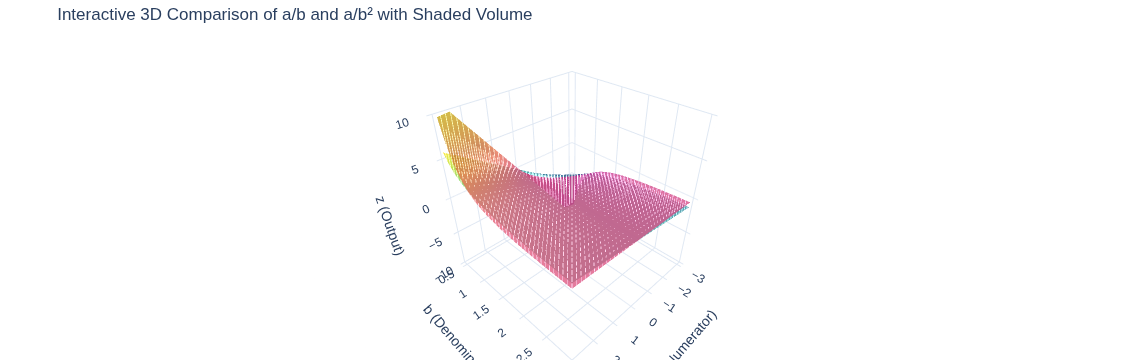

In [2]:
import numpy as np
import plotly.graph_objects as go

# 1. Create a coordinate grid for variables 'a' and 'b'
a_vals = np.linspace(-3, 3, 35)
b_vals = np.linspace(0.5, 3, 35)  # Keeps 'b' safely away from 0
A, B = np.meshgrid(a_vals, b_vals)

# 2. Calculate both surfaces
Z1 = A / B
Z2 = A / (B**2)

fig = go.Figure()

# 3. Add the first surface (z = a/b)
fig.add_trace(go.Surface(
    x=A, y=B, z=Z1,
    colorscale='Viridis',
    name='z = a/b',
    showscale=False,
    opacity=0.8
))

# 4. Add the second surface (z = a/b²)
fig.add_trace(go.Surface(
    x=A, y=B, z=Z2,
    colorscale='Plasma',
    name='z = a/b²',
    showscale=False,
    opacity=0.8
))

# 5. Construct the vertical "shading" lines between the two surfaces
x_lines = []
y_lines = []
z_lines = []

for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        # Connect (a, b, z1) straight to (a, b, z2)
        x_lines.extend([A[i, j], A[i, j], None])
        y_lines.extend([B[i, j], B[i, j], None])
        z_lines.extend([Z1[i, j], Z2[i, j], None])

fig.add_trace(go.Scatter3d(
    x=x_lines, y=y_lines, z=z_lines,
    mode='lines',
    line=dict(color='rgba(128, 128, 128, 0.25)', width=1.5),
    name='Region Between Surfaces',
    hoverinfo='none'
))

# 6. Set up the layout
fig.update_layout(
    title="Interactive 3D Comparison of a/b and a/b² with Shaded Volume",
    scene=dict(
        xaxis_title='a (Numerator)',
        yaxis_title='b (Denominator)',
        zaxis_title='z (Output)',
        zaxis=dict(range=[-10, 10])  # Limits runaway vertical values
    ),
    template="plotly_white",
    margin=dict(l=0, r=0, b=0, t=40)
)

# Render inside your browser
fig.show()